<a href="https://colab.research.google.com/github/Varun77331/KNN-assignmnet/blob/main/KNN_assignment_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.decomposition import PCA

In [ ]:
# 1. Load the Dataset

df = pd.read_csv("Zoo.csv")

print("First 5 rows of dataset")
print(df.head())

print("\nDataset Information")
print(df.info())

First 5 rows of dataset
  animal name  hair  feathers  eggs  milk  airborne  aquatic  predator  \
0    aardvark     1         0     0     1         0        0         1   
1    antelope     1         0     0     1         0        0         0   
2        bass     0         0     1     0         0        1         1   
3        bear     1         0     0     1         0        0         1   
4        boar     1         0     0     1         0        0         1   

   toothed  backbone  breathes  venomous  fins  legs  tail  domestic  catsize  \
0        1         1         1         0     0     4     0         0        1   
1        1         1         1         0     0     4     1         0        1   
2        1         1         0         0     1     0     1         0        0   
3        1         1         1         0     0     4     0         0        1   
4        1         1         1         0     0     4     1         0        1   

   type  
0     1  
1     1  
2     4  
3   

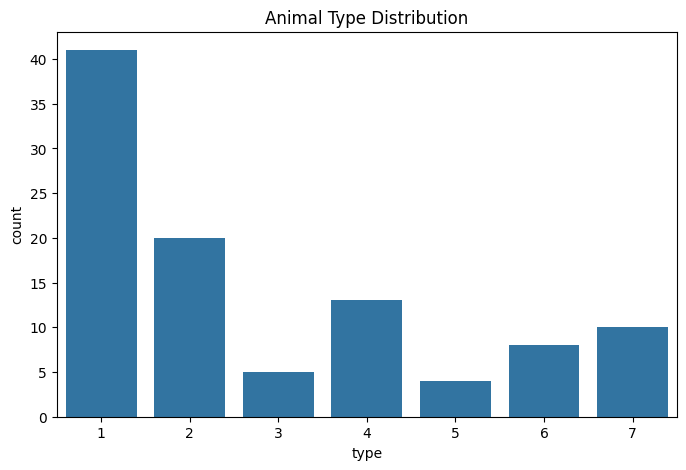

In [ ]:
# 2. Data Visualization-

plt.figure(figsize=(8,5))
sns.countplot(x='type', data=df)
plt.title("Animal Type Distribution")
plt.show()


In [ ]:
# 3. Check Missing Values

print("\nMissing values in dataset")
print(df.isnull().sum())



Missing values in dataset
animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


In [ ]:
# 4. Preprocessing

# animal name is just an identifier so I removed it
X = df.drop(['animal name','type'], axis=1)
y = df['type']


In [ ]:
# 5. Train Test Split

# I split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# 6. Apply KNN Model

# I selected K = 5 as a reasonable starting value
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [ ]:
# 7. Predictions

y_pred = knn.predict(X_test)



In [ ]:
# 8. Model Evaluation

print("\nModel Performance")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Model Performance
Accuracy : 0.9047619047619048
Precision: 0.9047619047619048
Recall   : 0.9047619047619048
F1 Score : 0.8957902001380263

Classification Report
              precision    recall  f1-score   support

           1       1.00      0.92      0.96        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.50      1.00      0.67         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.90        21
   macro avg       0.75      0.82      0.77        21
weighted avg       0.90      0.90      0.90        21



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


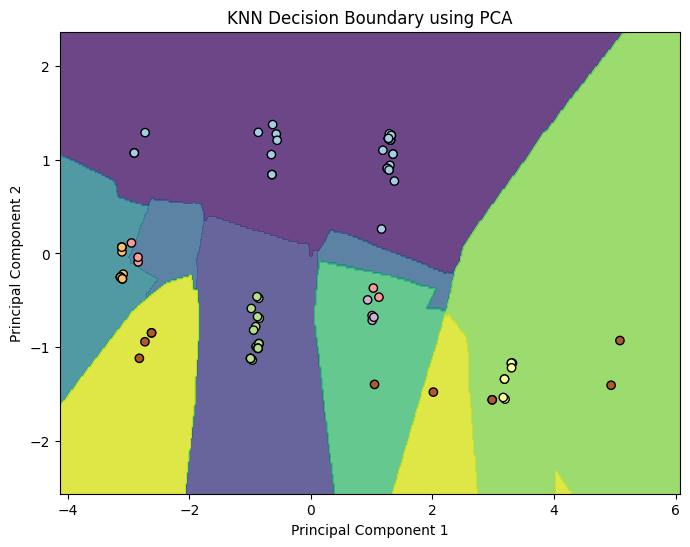

In [ ]:
# 9. Decision Boundary Visualization

# Since the dataset has many features, I used PCA to reduce it to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

knn_vis = KNeighborsClassifier(n_neighbors=5)
knn_vis.fit(X_pca, y)

# create mesh grid
h = 0.02
x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.8)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, edgecolor='k', cmap=plt.cm.Paired)

plt.title("KNN Decision Boundary using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

1. What are the key hyperparameters in KNN?

The main hyperparameters in KNN are:

K (number of neighbors) – number of nearest data points used for prediction

Distance metric – method used to measure distance between points

Weights – determines whether all neighbors contribute equally or closer neighbors have more influence

2. What distance metrics can be used in KNN?

Common distance metrics used in KNN include:

Euclidean Distance – most commonly used for continuous data

Manhattan Distance – useful for high-dimensional data

Minkowski Distance – general form of distance metric

Hamming Distance – used for categorical or binary features